# Quantum Fourier Transform (QFT) using Qiskit

## Overview

The Quantum Fourier Transform (QFT) is the quantum analogue of the classical Discrete Fourier Transform (DFT).

It transforms a quantum state from the computational basis into the frequency basis.

QFT is a fundamental building block of many quantum algorithms including:

- Phase Estimation
- Period Finding
- Order Finding
- Shor's Algorithm

---

## What QFT Does

Input:

|x⟩

Output:

A superposition whose amplitudes contain phase information.

QFT converts:

Time-domain information

into

Frequency-domain information

just like the classical Fourier Transform.

---

## Visualizations

- Circuit Diagrams
- Statevectors
- Bloch Spheres
- State City Plots
- Probability Histograms
- Amplitude Tables
- QFT vs Inverse QFT Verification

---

## Installation

pip install qiskit qiskit-aer matplotlib pylatexenc ipywidgets

---

Author: Muhammad Saad

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.5 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1378d6ef9bb5c1221b80f2d94b11cff9f51fa397e2f5ebb8b70a90b9793ca4b3
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit.circuit.library import QFT

from qiskit.visualization import (
    plot_histogram,
    plot_state_city,
    plot_bloch_multivector
)

from IPython.display import display

import ipywidgets as widgets

In [3]:
def visualize_state(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    print("\nProbabilities:")

    probs = state.probabilities_dict()

    for k,v in probs.items():
        print(f"{k}: {v:.4f}")

    display(plot_state_city(state))
    display(plot_bloch_multivector(state))

    return state

# What is QFT?

QFT transforms a quantum state into a frequency representation.

It is the quantum equivalent of the classical Fourier Transform.

QFT is used in:

- Phase Estimation
- Period Finding
- Order Finding
- Shor's Algorithm

In [4]:
state_dropdown = widgets.Dropdown(
    options=[
        "000","001","010","011",
        "100","101","110","111"
    ],
    value="101",
    description="Input State:"
)

display(state_dropdown)

Dropdown(description='Input State:', index=5, options=('000', '001', '010', '011', '100', '101', '110', '111')…


Selected State:
101
Input State


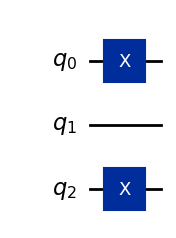


Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))

Probabilities:
101: 1.0000


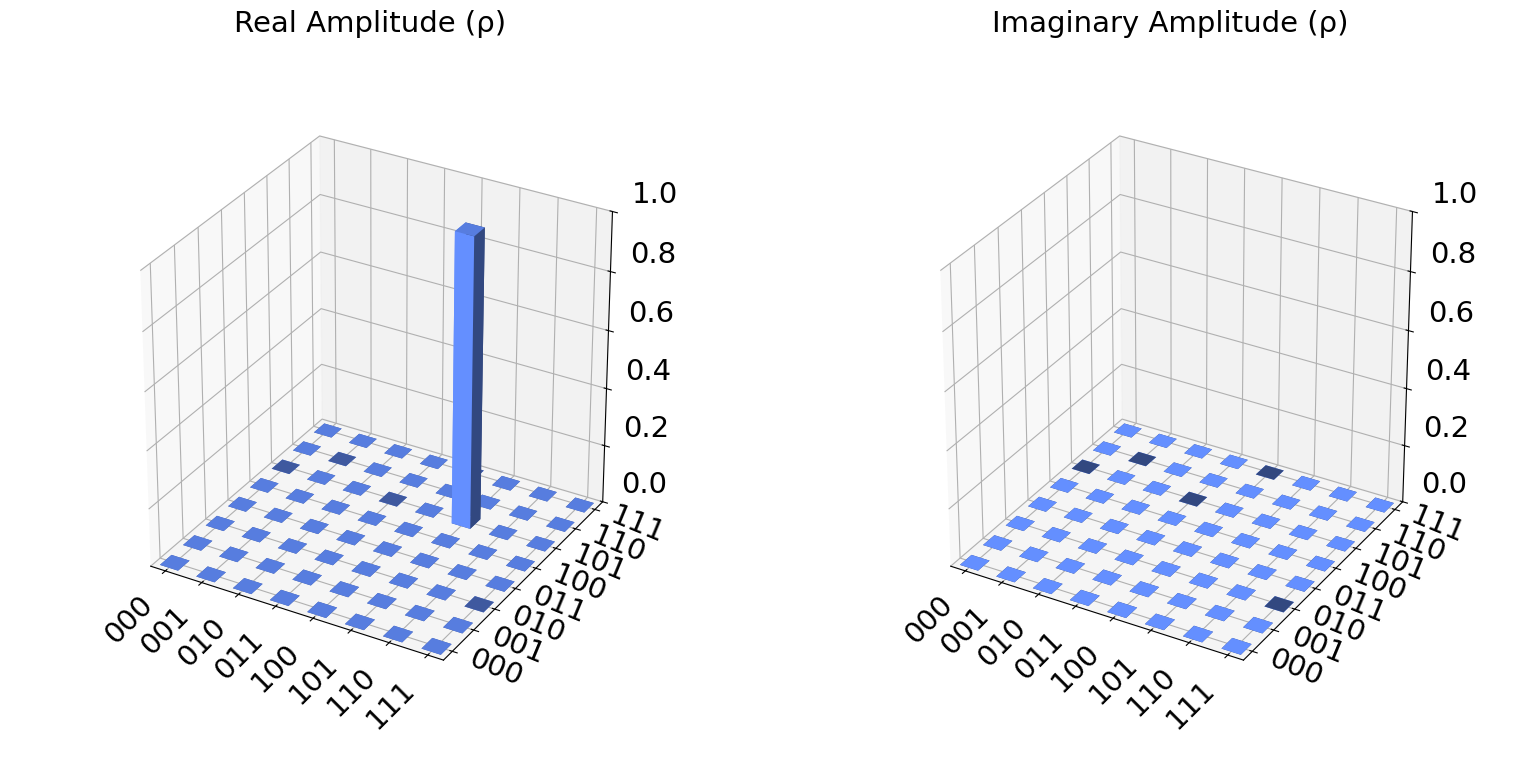

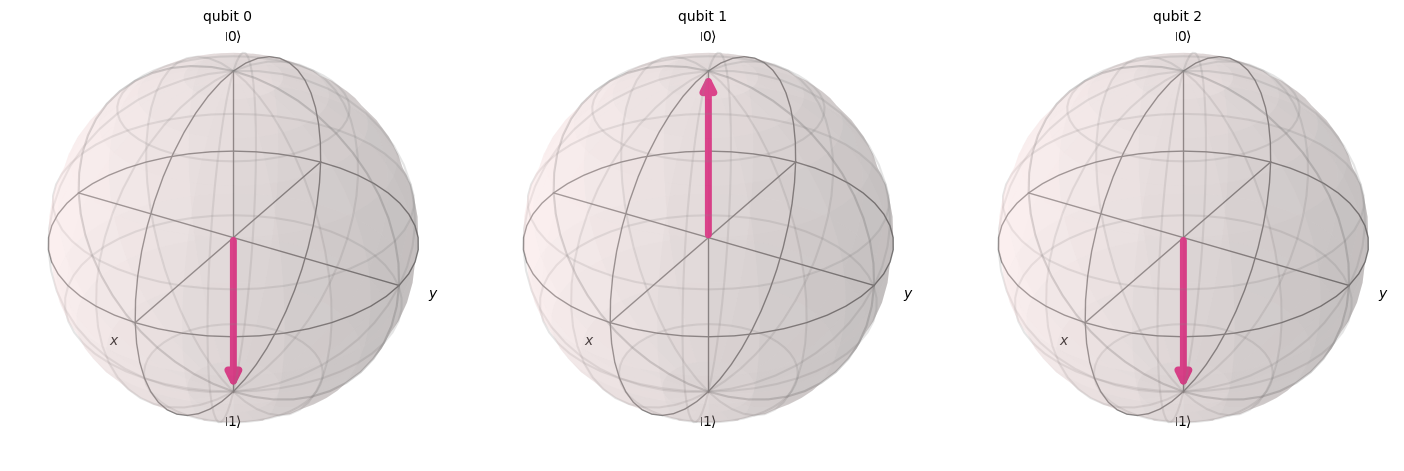

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


In [5]:
selected_state = state_dropdown.value

print()
print("Selected State:")
print(selected_state)

qc_input = QuantumCircuit(3)

for i,bit in enumerate(reversed(selected_state)):

    if bit == "1":
        qc_input.x(i)

visualize_state(
    qc_input,
    "Input State"
)

/tmp/ipykernel_3855/2249199532.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(


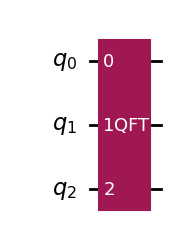

In [6]:
qft = QFT(
    num_qubits=3,
    do_swaps=True
)

display(
    qft.draw("mpl")
)

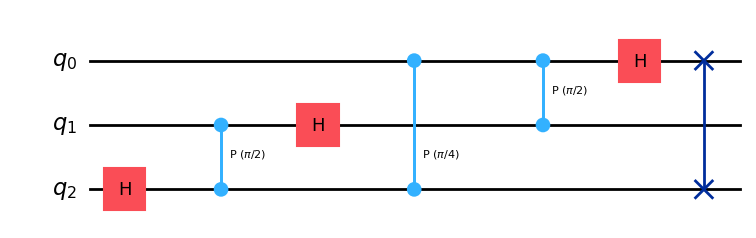

In [7]:
display(
    qft.decompose().draw("mpl")
)

After QFT


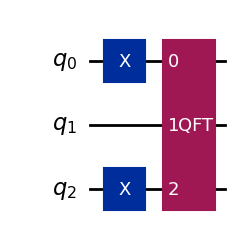


Statevector:
Statevector([ 3.53553391e-01+0.j        , -2.50000000e-01-0.25j      ,
              2.16489014e-17+0.35355339j,  2.50000000e-01-0.25j      ,
             -3.53553391e-01+0.j        ,  2.50000000e-01+0.25j      ,
             -2.16489014e-17-0.35355339j, -2.50000000e-01+0.25j      ],
            dims=(2, 2, 2))

Probabilities:
000: 0.1250
001: 0.1250
010: 0.1250
011: 0.1250
100: 0.1250
101: 0.1250
110: 0.1250
111: 0.1250


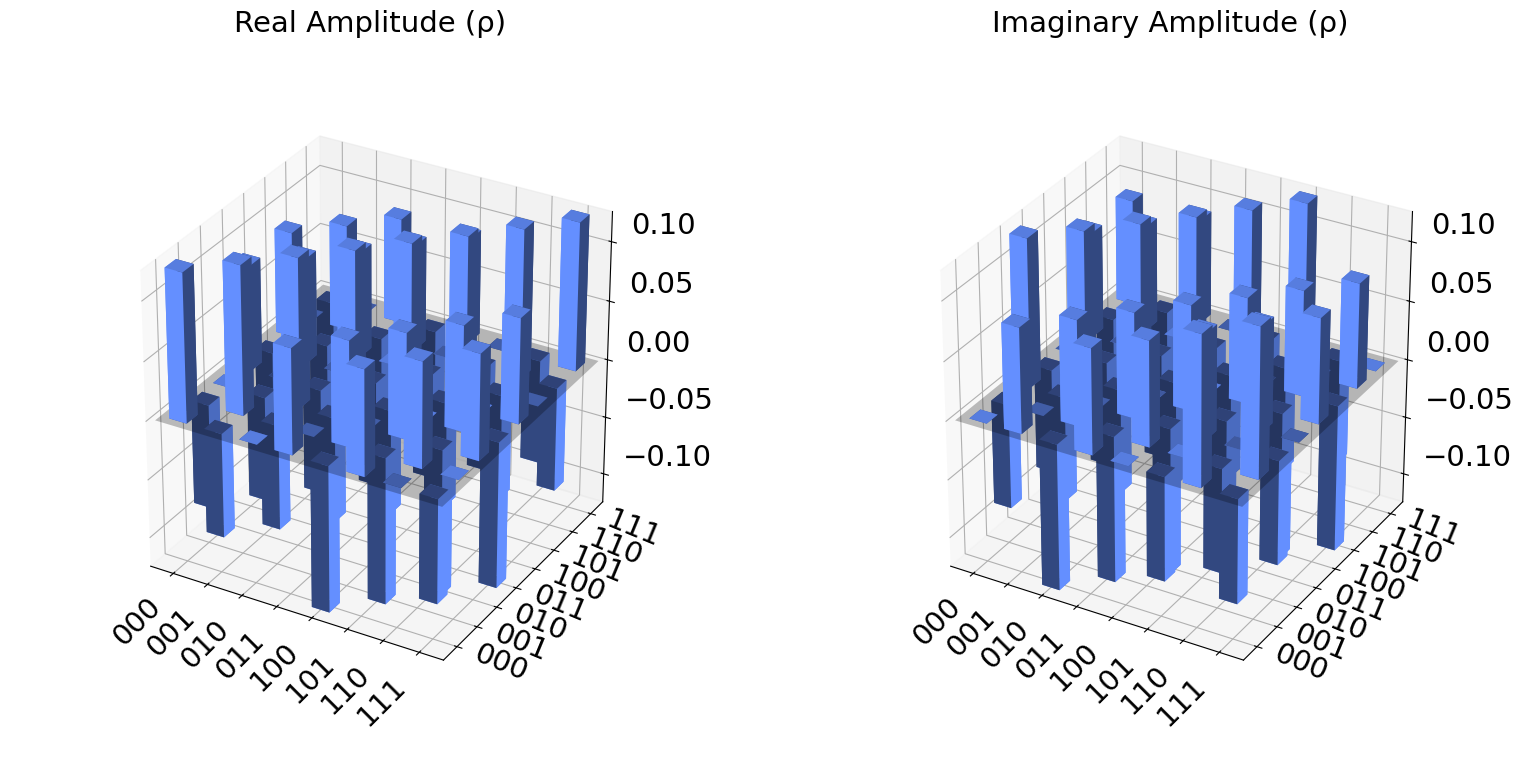

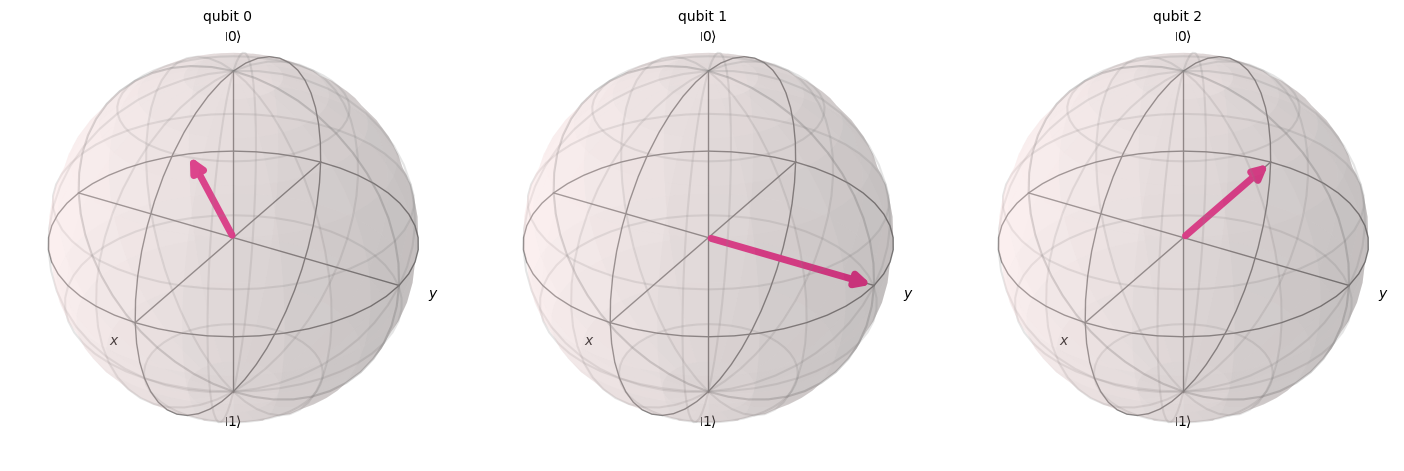

In [8]:
qc_qft = qc_input.copy()

qc_qft.compose(
    qft,
    inplace=True
)

state_after = visualize_state(
    qc_qft,
    "After QFT"
)

In [9]:
print("="*60)
print("AMPLITUDE ANALYSIS")
print("="*60)

for basis,amp in state_after.to_dict().items():

    print(
        basis,
        "Amplitude =",
        np.round(amp,4)
    )

AMPLITUDE ANALYSIS
000 Amplitude = (0.3536+0j)
001 Amplitude = (-0.25-0.25j)
010 Amplitude = 0.3536j
011 Amplitude = (0.25-0.25j)
100 Amplitude = (-0.3536+0j)
101 Amplitude = (0.25+0.25j)
110 Amplitude = (-0-0.3536j)
111 Amplitude = (-0.25+0.25j)


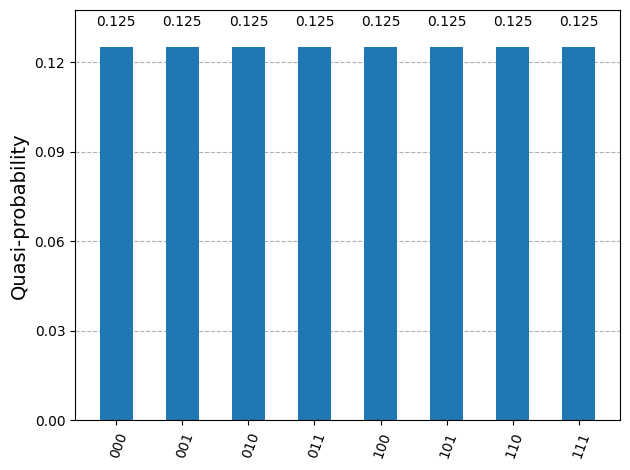

In [10]:
probs = state_after.probabilities_dict()

display(
    plot_histogram(probs)
)

In [11]:
print("="*60)
print("WHAT JUST HAPPENED?")
print("="*60)

print()

print("Before QFT:")

print(selected_state)

print()

print("After QFT:")

print("Information spread across all basis states.")

print()

print("Probabilities are similar.")

print()

print("The important information is now encoded in phases.")

WHAT JUST HAPPENED?

Before QFT:
101

After QFT:
Information spread across all basis states.

Probabilities are similar.

The important information is now encoded in phases.


In [12]:
from qiskit.circuit.library import QFT

inverse_qft = QFT(
    num_qubits=3,
    inverse=True,
    do_swaps=True
)

qc_verify = qc_qft.copy()

qc_verify.compose(
    inverse_qft,
    inplace=True
)

verify_state = Statevector.from_instruction(
    qc_verify
)

print()
print("Recovered State:")

print(verify_state)


Recovered State:
Statevector([-3.90912781e-18-7.27644378e-18j,
              2.36158002e-17+0.00000000e+00j,
              4.22029207e-18+7.27644378e-18j,
             -9.86264013e-19+6.05953219e-18j,
              4.22029207e-18+7.58760804e-18j,
              1.00000000e+00+0.00000000e+00j,
             -3.90912781e-18-7.58760804e-18j,
              1.05104718e-17-6.05953219e-18j],
            dims=(2, 2, 2))


/tmp/ipykernel_3855/893274004.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  inverse_qft = QFT(


After Inverse QFT


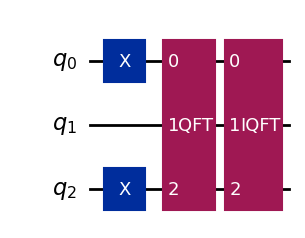


Statevector:
Statevector([-3.90912781e-18-7.27644378e-18j,
              2.36158002e-17+0.00000000e+00j,
              4.22029207e-18+7.27644378e-18j,
             -9.86264013e-19+6.05953219e-18j,
              4.22029207e-18+7.58760804e-18j,
              1.00000000e+00+0.00000000e+00j,
             -3.90912781e-18-7.58760804e-18j,
              1.05104718e-17-6.05953219e-18j],
            dims=(2, 2, 2))

Probabilities:
000: 0.0000
001: 0.0000
010: 0.0000
011: 0.0000
100: 0.0000
101: 1.0000
110: 0.0000
111: 0.0000


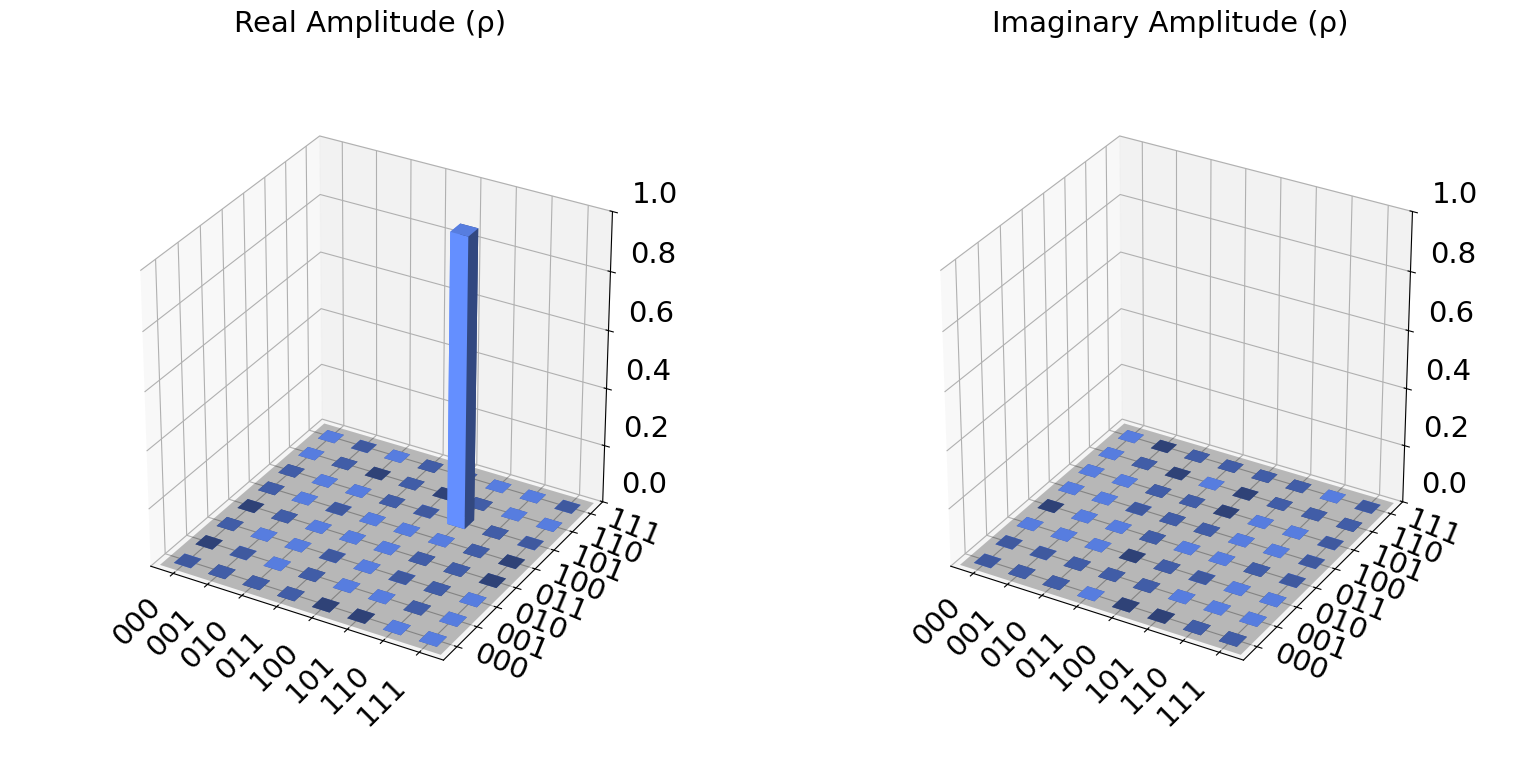

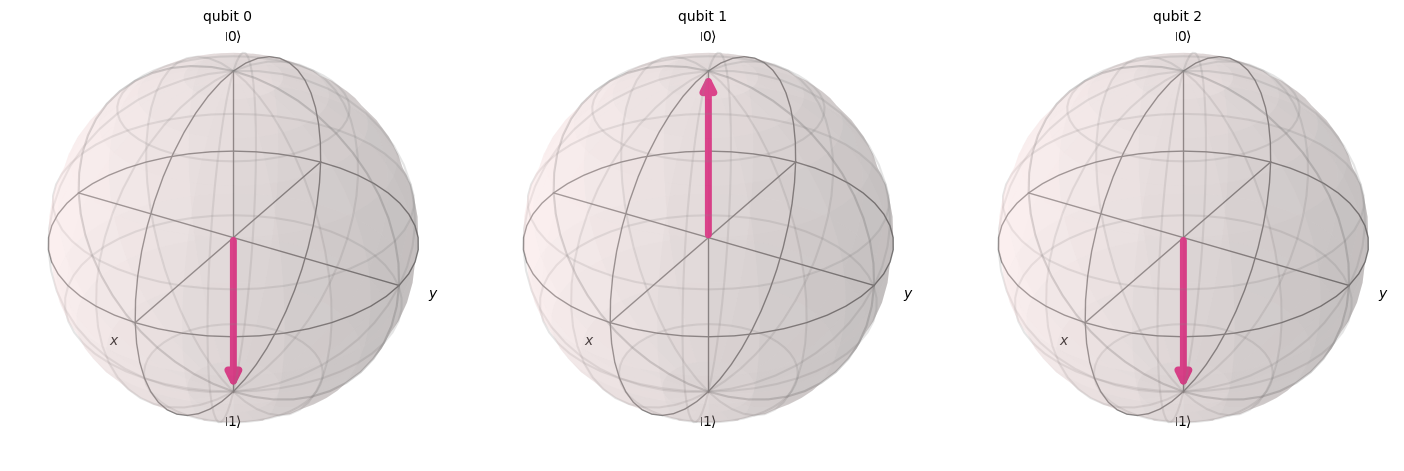

Statevector([-3.90912781e-18-7.27644378e-18j,
              2.36158002e-17+0.00000000e+00j,
              4.22029207e-18+7.27644378e-18j,
             -9.86264013e-19+6.05953219e-18j,
              4.22029207e-18+7.58760804e-18j,
              1.00000000e+00+0.00000000e+00j,
             -3.90912781e-18-7.58760804e-18j,
              1.05104718e-17-6.05953219e-18j],
            dims=(2, 2, 2))


In [13]:
visualize_state(
    qc_verify,
    "After Inverse QFT"
)

In [14]:
from qiskit.quantum_info import state_fidelity

original = Statevector.from_instruction(
    qc_input
)

recovered = Statevector.from_instruction(
    qc_verify
)

fidelity = state_fidelity(
    original,
    recovered
)

print()
print("State Fidelity:",fidelity)


State Fidelity: 0.9999999999999991


In [15]:
print("="*60)
print("CLASSICAL ANALOGY")
print("="*60)

print()

print("MP3 files use Fourier ideas.")

print("Image compression uses Fourier ideas.")

print("Signal processing uses Fourier ideas.")

print()

print("QFT is the quantum version of this concept.")

CLASSICAL ANALOGY

MP3 files use Fourier ideas.
Image compression uses Fourier ideas.
Signal processing uses Fourier ideas.

QFT is the quantum version of this concept.
